In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest

from sklearn.utils import resample

In [2]:
df = pd.read_csv("fraud_oracle.csv") 

print(df.head())
print(df.info())
print(df.columns)

  Month  WeekOfMonth  DayOfWeek    Make AccidentArea DayOfWeekClaimed  \
0   Dec            5  Wednesday   Honda        Urban          Tuesday   
1   Jan            3  Wednesday   Honda        Urban           Monday   
2   Oct            5     Friday   Honda        Urban         Thursday   
3   Jun            2   Saturday  Toyota        Rural           Friday   
4   Jan            5     Monday   Honda        Urban          Tuesday   

  MonthClaimed  WeekOfMonthClaimed     Sex MaritalStatus  ...  AgeOfVehicle  \
0          Jan                   1  Female        Single  ...       3 years   
1          Jan                   4    Male        Single  ...       6 years   
2          Nov                   2    Male       Married  ...       7 years   
3          Jul                   1    Male       Married  ...   more than 7   
4          Feb                   2  Female        Single  ...       5 years   

  AgeOfPolicyHolder PoliceReportFiled WitnessPresent AgentType  \
0          26 to 30 

In [3]:
# Drop unnecessary columns if exist
df.drop(columns=['PolicyNumber'], errors='ignore', inplace=True)

# Handle missing values
df.ffill(inplace=True)

In [4]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])
    
X = df.drop("FraudFound_P", axis=1)   # target column (check name if different)
y = df["FraudFound_P"]

In [5]:
# Combine
data = pd.concat([X, y], axis=1)

# Separate classes
fraud = data[data["FraudFound_P"] == 1]
normal = data[data["FraudFound_P"] == 0]

# Upsample fraud
fraud_upsampled = resample(fraud,replace=True,n_samples=len(normal),random_state=42)

# Combine balanced data
balanced = pd.concat([normal, fraud_upsampled])

X = balanced.drop("FraudFound_P", axis=1)
y = balanced["FraudFound_P"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [7]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
LR = LogisticRegression()

LR.fit(X_train, y_train)

y_pred = LR.predict(X_test)

print("Logistic Regression")
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Logistic Regression
[[1731 1153]
 [ 316 2599]]
              precision    recall  f1-score   support

           0       0.85      0.60      0.70      2884
           1       0.69      0.89      0.78      2915

    accuracy                           0.75      5799
   macro avg       0.77      0.75      0.74      5799
weighted avg       0.77      0.75      0.74      5799



In [9]:
RF = RandomForestClassifier(n_estimators=100)

RF.fit(X_train, y_train)

y_pred = RF.predict(X_test)

print("Random Forest")
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Random Forest
[[2881    3]
 [   0 2915]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2884
           1       1.00      1.00      1.00      2915

    accuracy                           1.00      5799
   macro avg       1.00      1.00      1.00      5799
weighted avg       1.00      1.00      1.00      5799



In [10]:
iso = IsolationForest(contamination=0.1)

iso.fit(X_train)

y_pred_iso = iso.predict(X_test)

# Convert output (-1 → fraud, 1 → normal)
y_pred_iso = np.where(y_pred_iso == -1, 1, 0)

print("Isolation Forest")
print(confusion_matrix(y_test, y_pred_iso))
print(classification_report(y_test, y_pred_iso))

Isolation Forest
[[2549  335]
 [2646  269]]
              precision    recall  f1-score   support

           0       0.49      0.88      0.63      2884
           1       0.45      0.09      0.15      2915

    accuracy                           0.49      5799
   macro avg       0.47      0.49      0.39      5799
weighted avg       0.47      0.49      0.39      5799



In [11]:
cv_scores = cross_val_score(RF, X, y, cv=5, scoring='recall')

print("Cross-validation Recall:", cv_scores)
print("Average Recall:", cv_scores.mean())

Cross-validation Recall: [1. 1. 1. 1. 1.]
Average Recall: 1.0


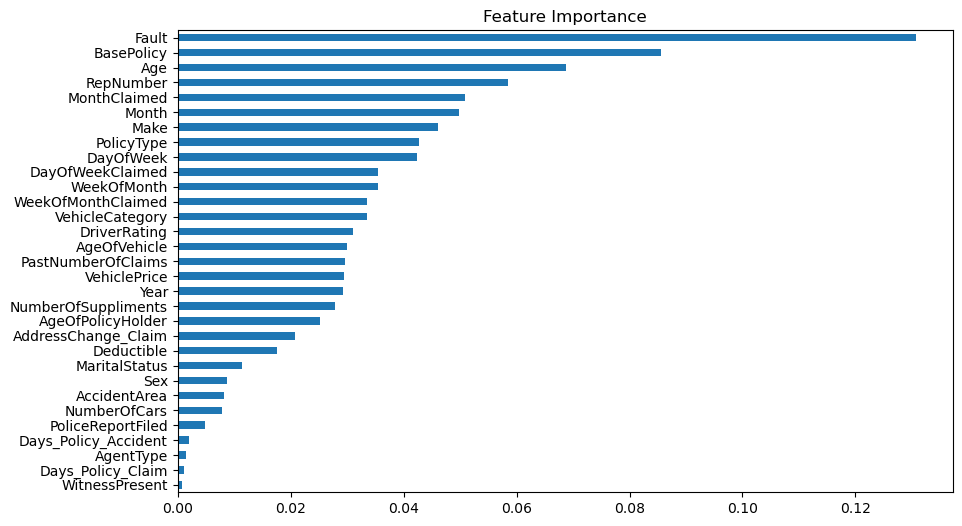

In [12]:
importances = RF.feature_importances_
features = pd.Series(importances, index=df.drop("FraudFound_P", axis=1).columns)

features.sort_values().plot(kind='barh', figsize=(10,6))
plt.title("Feature Importance")
plt.show()

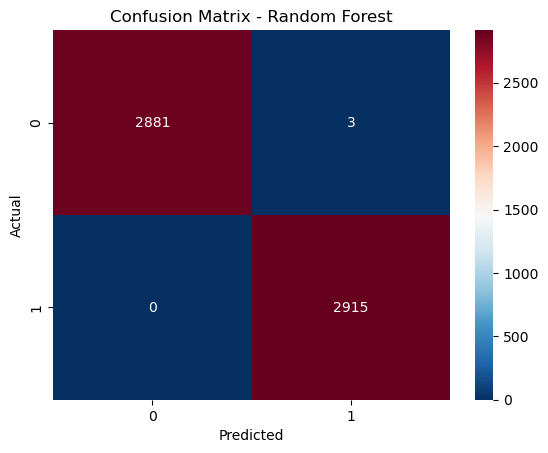

In [13]:
sns.heatmap(confusion_matrix(y_test, y_pred),
            annot=True, fmt='d', cmap='RdBu_r')

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [14]:
probabilities = RF.predict_proba(X_test)[:,1]

risk_df = pd.DataFrame({
    "Actual": y_test,
    "Fraud_Probability": probabilities
})

print(risk_df.head())

       Actual  Fraud_Probability
3084        0               0.00
13009       0               0.01
13217       0               0.08
5228        1               1.00
12213       1               1.00
